INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None

Número de filas:
30

Número de columnas:
2

Nombres de las columnas:
Index(['YearsExperience', 'Salary'], dtype='object')

ESTADÍSTICAS DESCRIPTIVAS
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000

Cantidad de datos:
YearsExperience    30
Salary             30
dtype: int64

Media:
YearsExperience        5.313333
Salary             7600

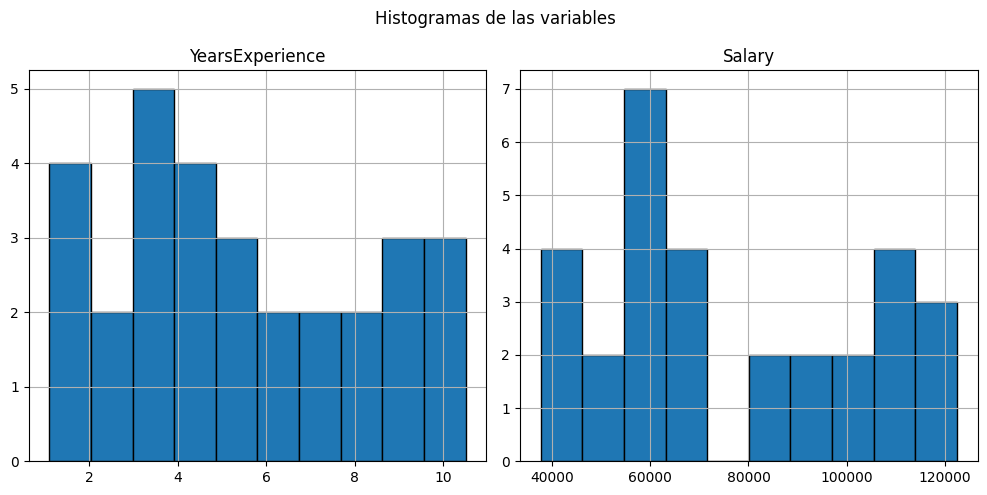

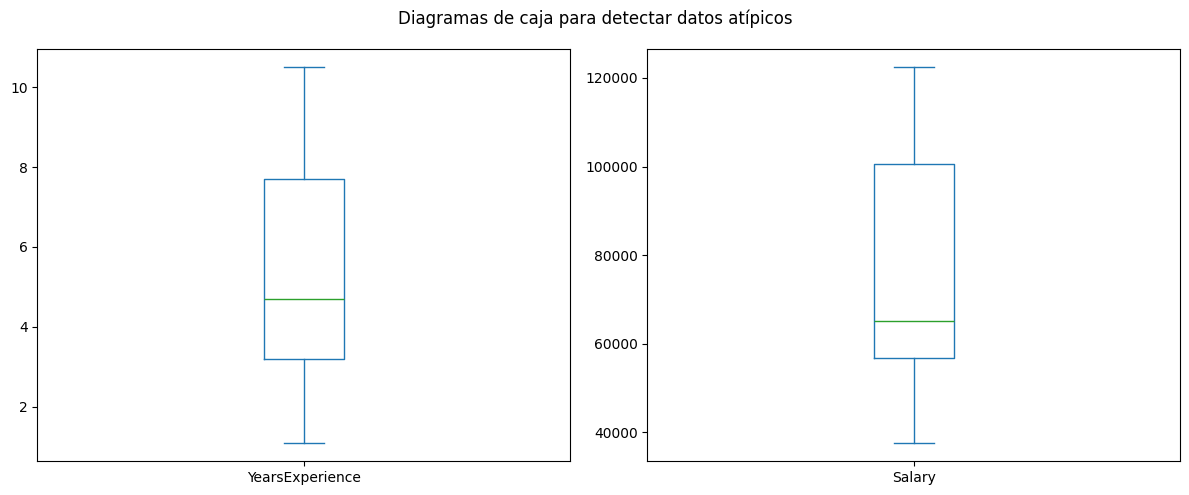


DETECCIÓN DE DATOS ATÍPICOS MEDIANTE IQR

Variable: YearsExperience
Q1: 3.2
Q3: 7.7
IQR: 4.5
Límite inferior: -3.55
Límite superior: 14.45
Cantidad de datos atípicos: 0
No se encontraron datos atípicos.

Variable: Salary
Q1: 56720.75
Q3: 100544.75
IQR: 43824.0
Límite inferior: -9015.25
Límite superior: 166280.75
Cantidad de datos atípicos: 0
No se encontraron datos atípicos.


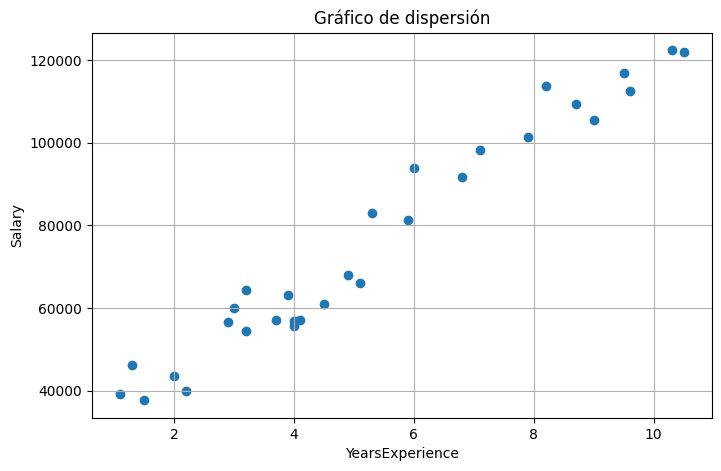


MATRIZ DE CORRELACIÓN
                 YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


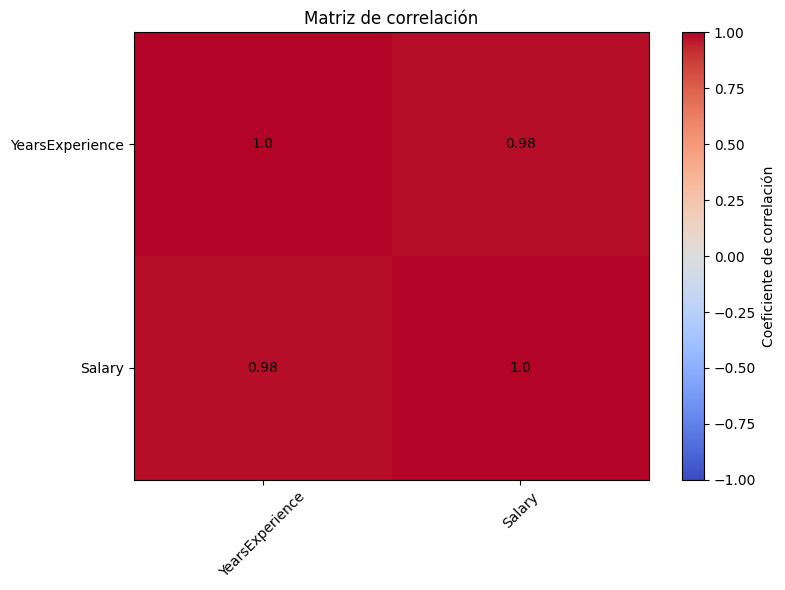

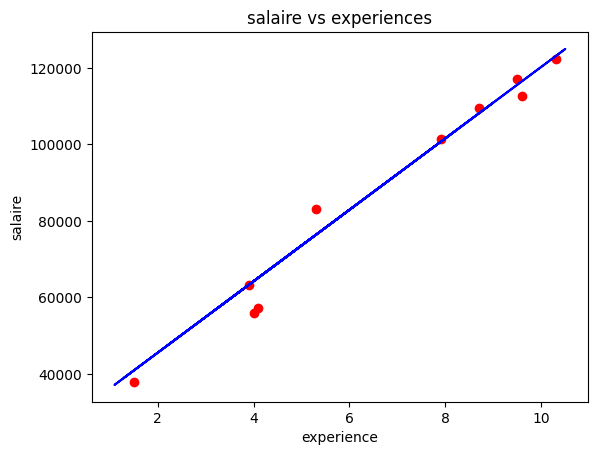

In [ ]:
# Proyecto Cargar Archivos y Graficar

# Importar las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Cargar la data en el proyecto
dataset=pd.read_csv('salary_data.csv')
X=dataset.iloc[:, :-1].values
y=dataset.iloc[:, -1].values


# Escribir la data
dataset.describe()


# ==========================================================
# ANÁLISIS EXPLORATORIO DE DATOS
# ==========================================================

# Mostrar información general del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print(dataset.info())

print("\nNúmero de filas:")
print(dataset.shape[0])

print("\nNúmero de columnas:")
print(dataset.shape[1])

print("\nNombres de las columnas:")
print(dataset.columns)


# ==========================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ==========================================================

print("\nESTADÍSTICAS DESCRIPTIVAS")
print(dataset.describe())

print("\nCantidad de datos:")
print(dataset.count())

print("\nMedia:")
print(dataset.mean(numeric_only=True))

print("\nMediana:")
print(dataset.median(numeric_only=True))

print("\nValor mínimo:")
print(dataset.min(numeric_only=True))

print("\nValor máximo:")
print(dataset.max(numeric_only=True))

print("\nPrimer cuartil (25%):")
print(dataset.quantile(0.25, numeric_only=True))

print("\nSegundo cuartil - Mediana (50%):")
print(dataset.quantile(0.50, numeric_only=True))

print("\nTercer cuartil (75%):")
print(dataset.quantile(0.75, numeric_only=True))


# ==========================================================
# HISTOGRAMAS
# ==========================================================

dataset.hist(figsize=(10,5), bins=10, edgecolor="black")

plt.suptitle("Histogramas de las variables")
plt.tight_layout()
plt.show()


# ==========================================================
# DIAGRAMAS DE CAJA - DETECCIÓN VISUAL DE DATOS ATÍPICOS
# ==========================================================

dataset.plot(
    kind="box",
    subplots=True,
    layout=(1, len(dataset.select_dtypes(include=np.number).columns)),
    figsize=(12,5),
    sharex=False,
    sharey=False
)

plt.suptitle("Diagramas de caja para detectar datos atípicos")
plt.tight_layout()
plt.show()


# ==========================================================
# DETECCIÓN DE DATOS ATÍPICOS CON EL MÉTODO IQR
# ==========================================================

print("\nDETECCIÓN DE DATOS ATÍPICOS MEDIANTE IQR")

columnas_numericas = dataset.select_dtypes(include=np.number).columns

for columna in columnas_numericas:

    Q1 = dataset[columna].quantile(0.25)
    Q3 = dataset[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    atipicos = dataset[
        (dataset[columna] < limite_inferior) |
        (dataset[columna] > limite_superior)
    ]

    print("\nVariable:", columna)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)
    print("Cantidad de datos atípicos:", len(atipicos))

    if len(atipicos) > 0:
        print(atipicos)
    else:
        print("No se encontraron datos atípicos.")


# ==========================================================
# GRÁFICO DE DISPERSIÓN
# ==========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    dataset.iloc[:, 0],
    dataset.iloc[:, -1]
)

plt.title("Gráfico de dispersión")
plt.xlabel(dataset.columns[0])
plt.ylabel(dataset.columns[-1])
plt.grid()
plt.show()


# ==========================================================
# MATRIZ DE CORRELACIÓN
# ==========================================================

correlacion = dataset.corr(numeric_only=True)

print("\nMATRIZ DE CORRELACIÓN")
print(correlacion)


# ==========================================================
# GRÁFICO DE CORRELACIÓN
# ==========================================================

plt.figure(figsize=(8,6))

plt.imshow(
    correlacion,
    cmap="coolwarm",
    interpolation="none",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Coeficiente de correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

# Mostrar los valores de correlación dentro del gráfico
for i in range(len(correlacion.columns)):
    for j in range(len(correlacion.columns)):
        plt.text(
            j,
            i,
            round(correlacion.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


# ==========================================================
# Preparar e modelo de regresión y la gráfica con los datos
# ==========================================================

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=1.0/3,random_state=0)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


# Preparando la gráfica
y_pred=model.predict(X_test)
y_pred


# Preparar la gráfica
plt.scatter(X_test, y_test, color="red")
plt.plot(X_train, model.predict(X_train), color="blue")
plt.title("salaire vs experiences")
plt.xlabel("experience")
plt.ylabel("salaire")
a=plt.show()

## CONCLUSIÖN


A partir del análisis realizado se puede observar que los datos presentan una distribución bastante clara entre los años de experiencia y el salario. Las medidas estadísticas como la media, mediana, valores mínimos, máximos y cuartiles permiten conocer cómo se encuentran distribuidos los datos y cuál es su comportamiento general.

En los histogramas y diagramas de caja se puede identificar la forma en que se distribuyen los valores y verificar si existen datos atípicos. En este caso, no se observan valores que afecten de manera importante el comportamiento general de la información.

El gráfico de dispersión muestra que existe una tendencia positiva entre la experiencia y el salario, es decir, a medida que aumentan los años de experiencia también tiende a aumentar el salario.

Finalmente, el análisis de correlación confirma esta relación entre las variables. En general, los gráficos y las medidas estadísticas muestran que los datos tienen un comportamiento coherente y que los años de experiencia tienen una relación directa con el salario.
